In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("list_attr_celeba.csv")

print(df.shape)
print(df.head())

(202599, 41)
     image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
0  000001.jpg                -1                1           1               -1   
1  000002.jpg                -1               -1          -1                1   
2  000003.jpg                -1               -1          -1               -1   
3  000004.jpg                -1               -1           1               -1   
4  000005.jpg                -1                1           1               -1   

   Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  Sideburns  Smiling  \
0    -1     -1        -1        -1          -1  ...         -1        1   
1    -1     -1        -1         1          -1  ...         -1        1   
2    -1     -1         1        -1          -1  ...         -1       -1   
3    -1     -1        -1        -1          -1  ...         -1       -1   
4    -1     -1         1        -1          -1  ...         -1       -1   

   Straight_Hair  Wavy_Hair  Wearing_Earrings  We

In [5]:
X = df.drop("image_id", axis=1)

print(X.shape)

(202599, 40)


In [6]:
X = (X + 1) / 2

In [7]:
X = X.astype("float32").values

In [8]:
input_layer = layers.Input(shape=(40,))

encoded = layers.Dense(16, activation="relu")(input_layer)
encoded = layers.Dense(8, activation="relu")(encoded)

decoded = layers.Dense(16, activation="relu")(encoded)
decoded = layers.Dense(40, activation="sigmoid")(decoded)

autoencoder = Model(input_layer, decoded)

In [9]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

In [10]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 40)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 40)                  │             680 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,616 (6.31 KB)

 Trainable params: 1,616 (6.31 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = autoencoder.fit(
    X,
    X,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.1423 - val_loss: 0.1419
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.1411 - val_loss: 0.1404
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.1400 - val_loss: 0.1400
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.1394 - val_loss: 0.1392
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.1387 - val_loss: 0.1385
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.1382 - val_loss: 0.1382
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.1378 - val_loss: 0.1378
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.1375 - val_loss: 0.1375
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.1372 - val_loss: 0.1374
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.1369 - val_loss: 0.1368
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.1366 - val_loss: 0.1365
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/st

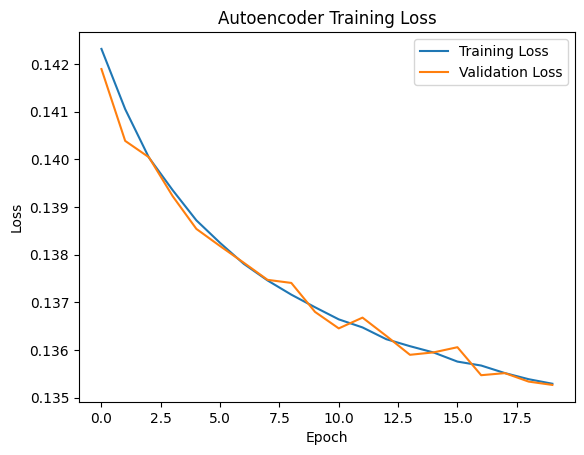

In [13]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")

plt.legend(["Training Loss", "Validation Loss"])
plt.show()

In [14]:
reconstructed = autoencoder.predict(X)

6332/6332 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step


In [15]:
print("Original:")
print(X[0])

print("\nReconstructed:")
print(reconstructed[0])

Original:
[0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0.
 1. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 0. 1.]

Reconstructed:
[2.9372266e-10 9.1995841e-01 9.8484951e-01 7.5574905e-02 1.4843194e-08
 3.6587539e-01 5.9061542e-02 1.6696567e-02 9.5681964e-05 2.6044421e-02
 1.0378239e-03 9.9506104e-01 1.2160240e-02 1.9174944e-05 6.4489359e-05
 1.8004826e-04 0.0000000e+00 9.0117521e-07 9.9223149e-01 9.9853456e-01
 4.2217998e-08 8.0072200e-01 4.2976438e-19 7.4157864e-02 1.0000000e+00
 5.6026481e-02 1.5865436e-02 5.7206076e-01 7.5052120e-02 1.7399666e-01
 0.0000000e+00 9.9909830e-01 9.9977529e-01 3.1211863e-07 6.2942827e-01
 1.6413044e-07 9.9989897e-01 2.4554668e-01 3.4175802e-05 9.6075910e-01]
